## Finding the Hate or Not Hate on Twitter Data Set
classification problem <br>
EDA,Data Cleaning [spacial chars, punctuations,stopwords], stemming(make it to root word) and lematization(original meaning), Tokenization and vectorization or word embidding, train test, training model, validation.

## EDA

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('imbalanced_data.csv')

In [3]:
df

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."


In [4]:
# from google.colab import drive
# drive.mount("/content/drive")

#### Data Cleaning

In [5]:
from nltk.corpus import stopwords
import re
import string
import nltk
nltk.download('stopwords')
stemmer = nltk.SnowballStemmer("english")
stopword = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /home/svm/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
def data_cleaning(words):
    words = str(words).lower()
    words = re.sub('\[.*?\]', '', words)
    words = re.sub('https?://\S+|www\.\S+', '', words)
    words = re.sub('<.*?>+', '', words)
    words = re.sub('[%s]' % re.escape(string.punctuation), '', words)
    words = re.sub('\n', '', words)
    words = re.sub('@', '', words)
    words = re.sub('ur.+', '', words)
    words = re.sub('ð.+', '', words)
    words = re.sub('\s[\s+]', '', words)
    words = re.sub('\w*\d\w*', '', words)
    words = [word for word in words.split(' ') if words not in stopword]
    words=" ".join(words)
    words = [stemmer.stem(words) for word in words.split(' ')]
    words=" ".join(words)

    return words

<>:3: SyntaxWarning: invalid escape sequence '\['
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\['
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_316237/3896601561.py:3: SyntaxWarning: invalid escape sequence '\['
  words = re.sub('\[.*?\]', '', words)
/tmp/ipykernel_316237/3896601561.py:4: SyntaxWarning: invalid escape sequence '\S'
  words = re.sub('https?://\S+|www\.\S+', '', words)
/tmp/ipykernel_316237/3896601561.py:11: SyntaxWarning: invalid escape sequence '\s'
  words = re.sub('\s[\s+]', '', words)
/tmp/ipykernel_316237/3896601561.py:12: SyntaxWarning: invalid escape sequence '\w'
  words = re.sub('\w*\d\w*', '', words)


In [7]:
df["tweet"]=df["tweet"].apply(data_cleaning)

In [8]:
df

,id,label,tweet
0,1,0,user when a father is dysfunctional and is so...
1,2,0,user user thanks for lyft credit i cant use ca...
2,3,0,bihday yo bihday yo
3,4,0,model i love u take with u all the time in mo...
4,5,0,factsguide society nowmotiv factsguide socie...
...,...,...,...
31957,31958,0,ate user isz that youuu ate user isz that youu...
31958,31959,0,to see nina t to see nina t to see nina t to s...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,user sikh temple vandalised in in calgary wso ...


### Document length

In [9]:
df["length"]=df['tweet'].apply(lambda x:len(x.split(" ")))

<Axes: xlabel='label', ylabel='count'>

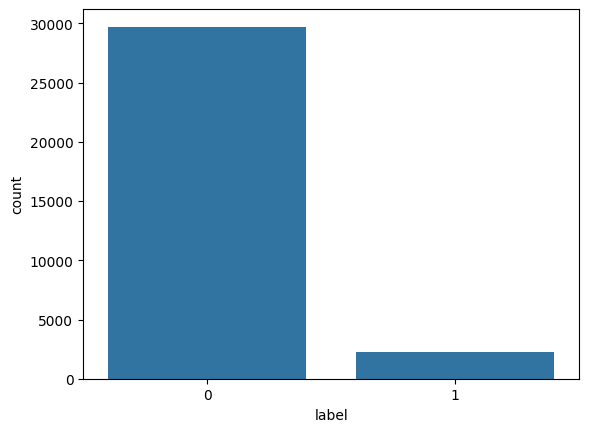

In [10]:
sns.countplot(x="label",data=df)

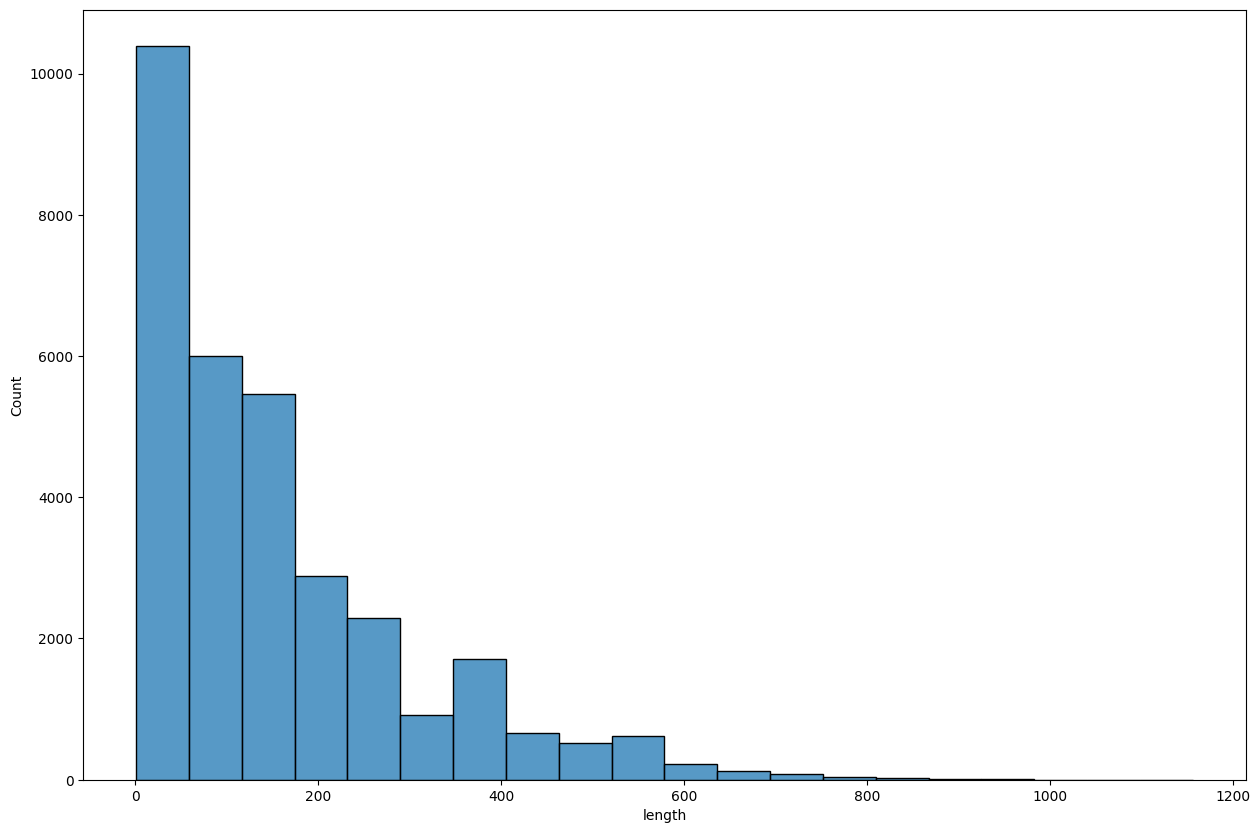

In [11]:
plt.figure(figsize=(15,10))
sns.histplot(data=df,x='length',bins=20)
plt.show()

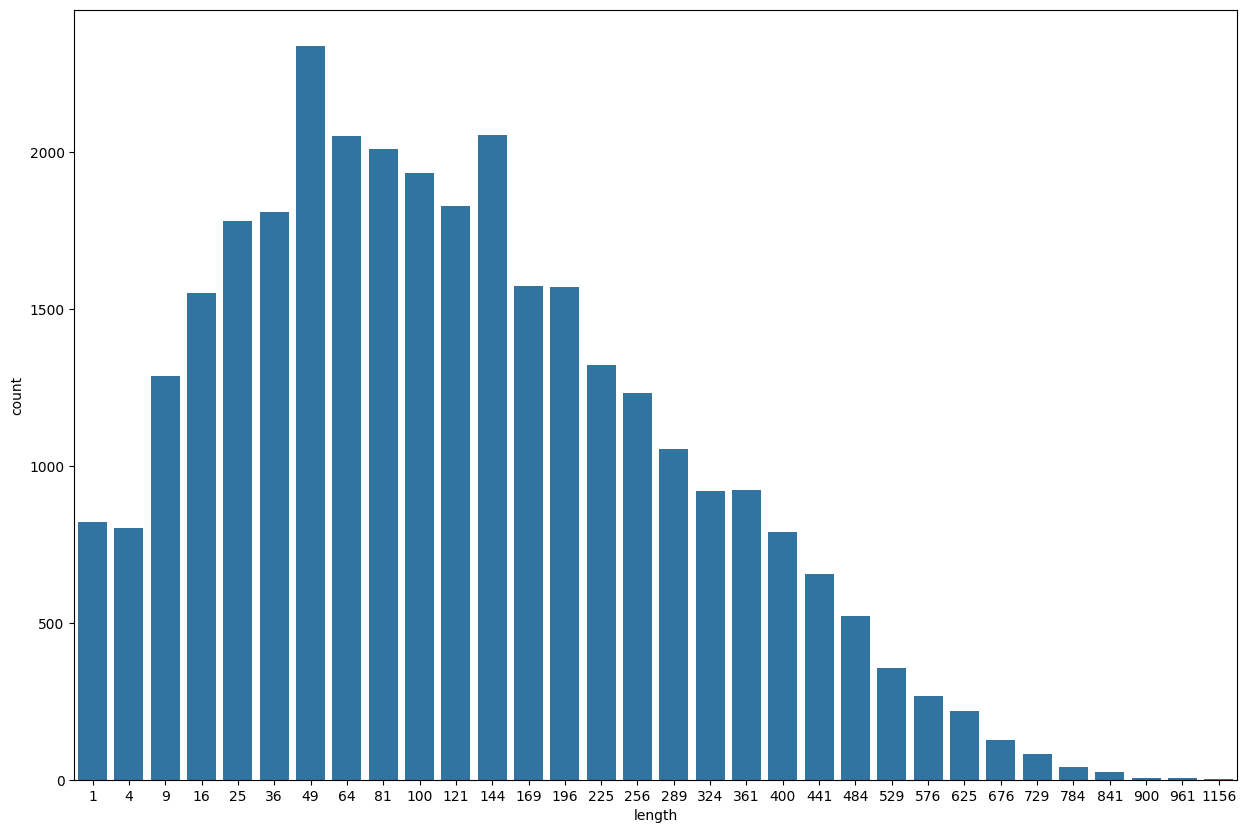

In [12]:
plt.figure(figsize=(15,10))
sns.countplot(data=df,x='length')
plt.show()

### Vocubalary size

In [ ]:
all_words=[]
for i in df['tweet']:
    for j in i.split():
        all_words.append(j)

In [14]:
len(all_words)

4638131

In [15]:
unq=set(all_words)

In [16]:
len(unq)

38616

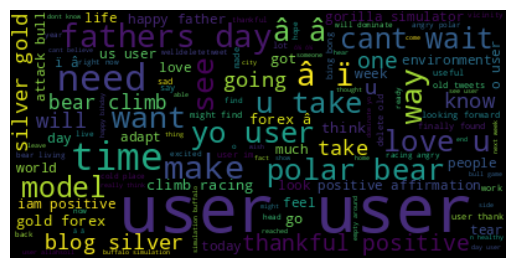

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
wordcloud = WordCloud().generate("".join(df["tweet"]))

# Display the generated image
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


## Modeling

In [18]:
import keras

2026-04-23 01:51:34.773633: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 01:51:34.809086: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-23 01:51:35.531942: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [19]:
x = df['tweet']
y = df['label']

In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [21]:
from keras.preprocessing.sequence import pad_sequences

In [22]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, random_state = 42,stratify=y)

print(len(x_train),len(y_train))
print(len(x_test),len(y_test))

23971 23971
7991 7991


In [23]:
max_words = 5000
max_len = 300

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(x_train)

In [24]:
sequences = tokenizer.texts_to_sequences(x_train)

In [25]:
sequences_matrix = pad_sequences(sequences,maxlen=max_len)

In [26]:
sequences_matrix

array([[   0,    0,    0, ...,   13,  237, 4767],
       [   0,    0,    0, ...,  425,   13,  244],
       [   0,    0,    0, ...,  790,  484,  790],
       ...,
       [   0,    0,    0, ...,    1,   10,  110],
       [   6,   86,   97, ...,    2,  158,  287],
       [   0,    0,    0, ...,    1,   17,    1]],
      shape=(23971, 300), dtype=int32)

In [27]:
model=keras.Sequential()
model.add(keras.layers.Input((23971,)))
model.add(keras.layers.Embedding(max_words, 100))
model.add(keras.layers.SimpleRNN(100, dropout=0.2, recurrent_dropout=0.2))
model.add(keras.layers.Dense(1, activation="sigmoid"))

model.summary()

I0000 00:00:1776889297.910176  316237 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2143 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 23971, 100)     │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 520,201 (1.98 MB)

 Trainable params: 520,201 (1.98 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [29]:
history = model.fit(sequences_matrix,y_train,batch_size=32,epochs = 10,validation_split=0.2)

Epoch 1/10


2026-04-23 01:51:39.201115: I external/local_xla/xla/service/service.cc:163] XLA service 0x7530880031a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-23 01:51:39.201133: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2026-04-23 01:51:39.223528: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-23 01:51:39.356453: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92100
2026-04-23 01:51:39.447337: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-23 01:51:39.447369: I e

  7/600 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.5124 - loss: 0.6988

I0000 00:00:1776889301.792320  317200 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8381 - loss: 0.3949

2026-04-23 01:51:53.836821: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-23 01:51:55.721039: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-23 01:51:55.721063: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


600/600 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.9036 - loss: 0.2969 - val_accuracy: 0.9274 - val_loss: 0.2522
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9338 - loss: 0.2224 - val_accuracy: 0.9351 - val_loss: 0.2077
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9392 - loss: 0.1906 - val_accuracy: 0.9389 - val_loss: 0.1973
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9160 - loss: 0.2275 - val_accuracy: 0.9099 - val_loss: 0.2245
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.9334 - loss: 0.1864 - val_accuracy: 0.9381 - val_loss: 0.2039
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9467 - loss: 0.1584 - val_accuracy: 0.9349 - val_loss: 0.2028
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9513 - loss: 0.1447 - val_accuracy: 0.9314 - val_loss: 0.2134
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9546 - loss: 0.1294 - val_accurac

In [30]:
test_sequences = tokenizer.texts_to_sequences(x_test)
test_sequences_matrix = pad_sequences(test_sequences,maxlen=max_len)

In [31]:
accr = model.evaluate(test_sequences_matrix,y_test)

249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9401 - loss: 0.2202

2026-04-23 01:53:41.800687: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-23 01:53:41.800712: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9399 - loss: 0.2114


In [32]:
rnn_prediction = model.predict(test_sequences_matrix)

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [38]:
rnn_prediction[33]

array([0.09789056], dtype=float32)

In [34]:
res = []
for prediction in rnn_prediction:
    if prediction[0] < 0.5:
        res.append(0)
    else:
        res.append(1)

In [35]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,res))

[[7311  119]
 [ 361  200]]


In [36]:
import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [37]:
model.save_weights('.weights.h5')